# Temporal Analysis of Scraped TikTok Results
This notebook cell analyzes posting and performance trends over time using `users_recent_videos.json` generated from the TikTokApi fetch job.

Videos analyzed: 1,797
Unique users represented: 34
Time range: 2022-09-21 11:08:09+00:00  ->  2026-03-19 11:58:57+00:00


,month,videos,total_plays,avg_plays
21,2025-04,31,8233807,2.656067e+05
22,2025-05,26,17790986,6.842687e+05
23,2025-06,16,28531815,1.783238e+06
24,2025-07,30,55868266,1.862276e+06
25,2025-08,27,25753976,9.538510e+05
26,2025-09,43,34918206,8.120513e+05
27,2025-10,62,10534691,1.699144e+05
28,2025-11,99,32942701,3.327546e+05
29,2025-12,152,50597567,3.328787e+05
30,2026-01,248,63935829,2.578058e+05


,weekday,videos,total_plays
1,Monday,262,52971197
5,Tuesday,267,56591138
6,Wednesday,281,134598496
4,Thursday,292,149044476
0,Friday,226,30985634
2,Saturday,221,67725849
3,Sunday,248,82526389


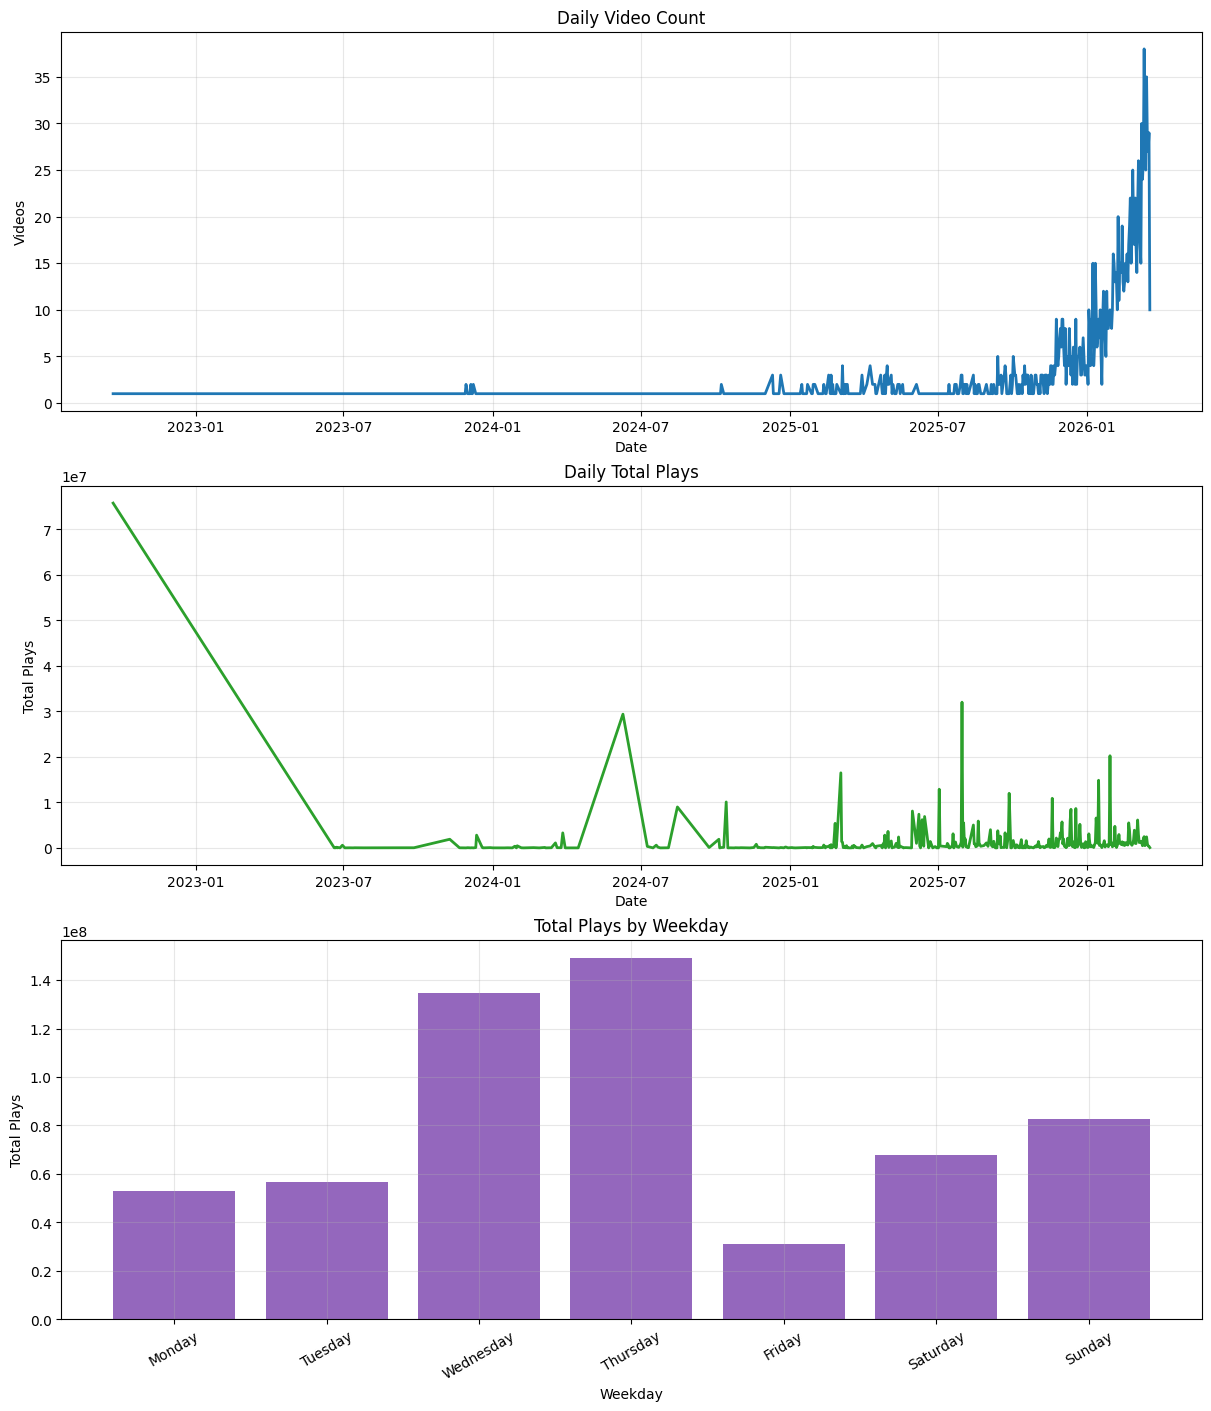

Top 10 dates by total plays:


,date,videos,total_plays,median_plays
0,2022-09-21,1,75800000,75800000.0
218,2025-07-31,3,32038900,11400000.0
60,2024-06-09,1,29400000,29400000.0
376,2026-01-29,10,20257130,21150.0
128,2025-03-04,1,16500000,16500000.0
362,2026-01-15,9,14868640,17600.0
200,2025-07-03,1,12900000,12900000.0
257,2025-09-27,1,12000000,12000000.0
305,2025-11-19,2,10904700,5452350.0
74,2024-10-14,1,10100000,10100000.0


In [3]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load output produced by main.py
data_path = Path('users_recent_videos.json')
if not data_path.exists():
    raise FileNotFoundError('users_recent_videos.json not found. Run the fetch script first.')

with data_path.open('r', encoding='utf-8') as f:
    payload = json.load(f)

results = payload.get('results', {})
rows = []

for username, videos in results.items():
    for v in videos or []:
        stats = v.get('stats') or {}
        author = v.get('author') or {}

        # Support both schemas: createTimeISO (string) and createTime (unix seconds)
        created_raw = v.get('createTimeISO')
        if created_raw is None:
            created_raw = v.get('createTime')

        # Build canonical URL if webVideoUrl is missing
        video_id = v.get('id')
        unique_id = author.get('uniqueId') or username
        url = v.get('webVideoUrl') or (f"https://www.tiktok.com/@{unique_id}/video/{video_id}" if video_id else None)

        rows.append({
            'username': username,
            'created_raw': created_raw,
            'playCount': pd.to_numeric(v.get('playCount', stats.get('playCount')), errors='coerce'),
            'diggCount': pd.to_numeric(v.get('diggCount', stats.get('diggCount')), errors='coerce'),
            'commentCount': pd.to_numeric(v.get('commentCount', stats.get('commentCount')), errors='coerce'),
            'shareCount': pd.to_numeric(v.get('shareCount', stats.get('shareCount')), errors='coerce'),
            'collectCount': pd.to_numeric(v.get('collectCount', stats.get('collectCount')), errors='coerce'),
            'duration': pd.to_numeric(v.get('videoMeta', {}).get('duration'), errors='coerce') if isinstance(v.get('videoMeta'), dict) else pd.NA,
            'url': url,
        })

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError('No videos available in results to analyze.')

# Parse timestamps robustly (unix seconds preferred, then ISO fallback)
numeric_created = pd.to_numeric(df['created_raw'], errors='coerce')
created_from_unix = pd.to_datetime(numeric_created, unit='s', utc=True, errors='coerce')
created_from_iso = pd.to_datetime(df['created_raw'], utc=True, errors='coerce')
df['created_at'] = created_from_unix.fillna(created_from_iso)

df = df.dropna(subset=['created_at']).copy()
if df.empty:
    raise ValueError('No valid timestamps found after parsing createTime/createTimeISO.')

df['date'] = df['created_at'].dt.date
df['month'] = df['created_at'].dt.strftime('%Y-%m')
df['weekday'] = df['created_at'].dt.day_name()

# Basic coverage summary
print(f"Videos analyzed: {len(df):,}")
print(f"Unique users represented: {df['username'].nunique():,}")
print(f"Time range: {df['created_at'].min()}  ->  {df['created_at'].max()}")

# Aggregations
daily = (
    df.groupby('date', as_index=False)
      .agg(
          videos=('url', 'count'),
          total_plays=('playCount', 'sum'),
          median_plays=('playCount', 'median')
      )
      .sort_values('date')
)

monthly = (
    df.groupby('month', as_index=False)
      .agg(
          videos=('url', 'count'),
          total_plays=('playCount', 'sum'),
          avg_plays=('playCount', 'mean')
      )
      .sort_values('month')
)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats = (
    df.groupby('weekday', as_index=False)
      .agg(videos=('url', 'count'), total_plays=('playCount', 'sum'))
)
weekday_stats['weekday'] = pd.Categorical(weekday_stats['weekday'], categories=weekday_order, ordered=True)
weekday_stats = weekday_stats.sort_values('weekday')

display(monthly.tail(12))
display(weekday_stats)

# Plot temporal trends
fig, axes = plt.subplots(3, 1, figsize=(12, 14), constrained_layout=True)

axes[0].plot(pd.to_datetime(daily['date']), daily['videos'], linewidth=2)
axes[0].set_title('Daily Video Count')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Videos')
axes[0].grid(alpha=0.3)

axes[1].plot(pd.to_datetime(daily['date']), daily['total_plays'], linewidth=2, color='tab:green')
axes[1].set_title('Daily Total Plays')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Plays')
axes[1].grid(alpha=0.3)

axes[2].bar(weekday_stats['weekday'].astype(str), weekday_stats['total_plays'], color='tab:purple')
axes[2].set_title('Total Plays by Weekday')
axes[2].set_xlabel('Weekday')
axes[2].set_ylabel('Total Plays')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(alpha=0.3)

plt.show()

# Top-performing dates
top_dates = daily.sort_values('total_plays', ascending=False).head(10)
print('Top 10 dates by total plays:')
display(top_dates)

## User-Level Growth Over Time
This section measures growth per user using monthly aggregates of videos and plays, then compares each user's first observed month vs latest observed month.

Users with >=3 months history: 32


/tmp/ipykernel_350843/3774034095.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  user_df['month_ts'] = user_df['created_at'].dt.to_period('M').dt.to_timestamp()


,username,month_ts_first,month_ts_last,months_span,total_plays_first,total_plays_last,plays_growth_abs,plays_growth_pct
11,jameswuantin,2025-07-01,2026-03-01,9,587700,3565400,2977700,506.670070
29,santiagohnndz_,2025-12-01,2026-03-01,4,286600,898607,612007,213.540475
2,calees.pe,2024-07-01,2026-03-01,21,163500,423278,259778,158.885627
10,iam.anayaaa,2025-06-01,2026-03-01,10,435500,648700,213200,48.955224
12,jazzyeungsy,2025-11-01,2026-03-01,5,5200000,5300000,100000,1.923077
4,danielfcc,2024-10-01,2026-03-01,18,3357,1314,-2043,-60.857909
21,mrmikeju,2023-11-01,2026-02-01,28,12887,1406,-11481,-89.089780
20,mosznss,2025-11-01,2026-03-01,5,44559,11772,-32787,-73.581095
17,maniirare,2023-12-01,2026-03-01,28,60200,3931,-56269,-93.470100
15,lucasferryfits,2026-01-01,2026-03-01,3,134277,71042,-63235,-47.092950


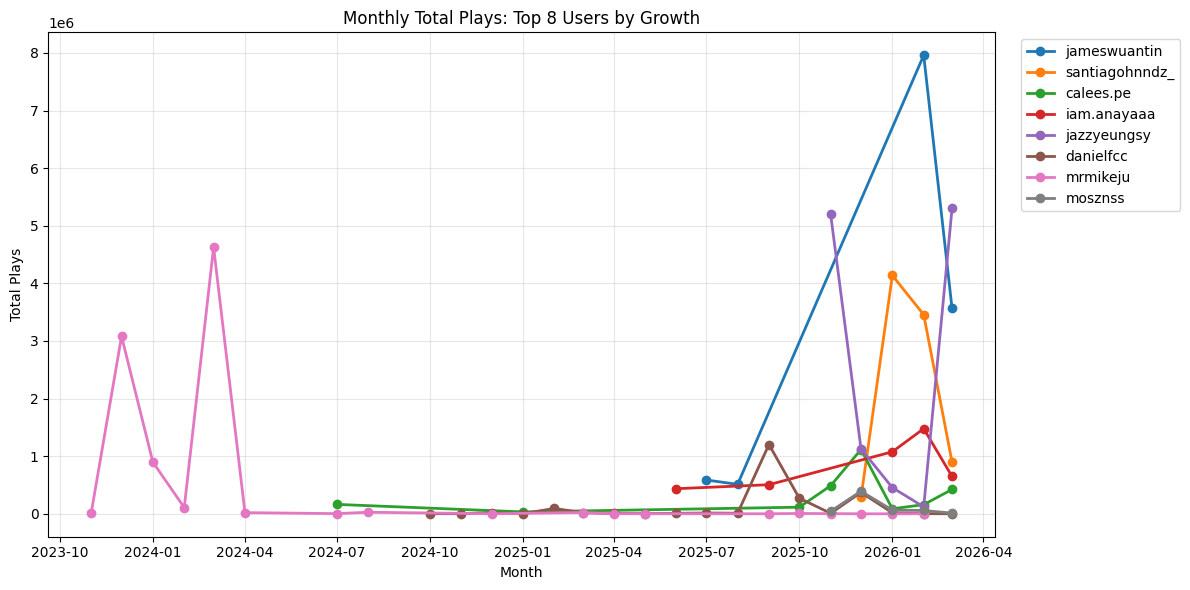

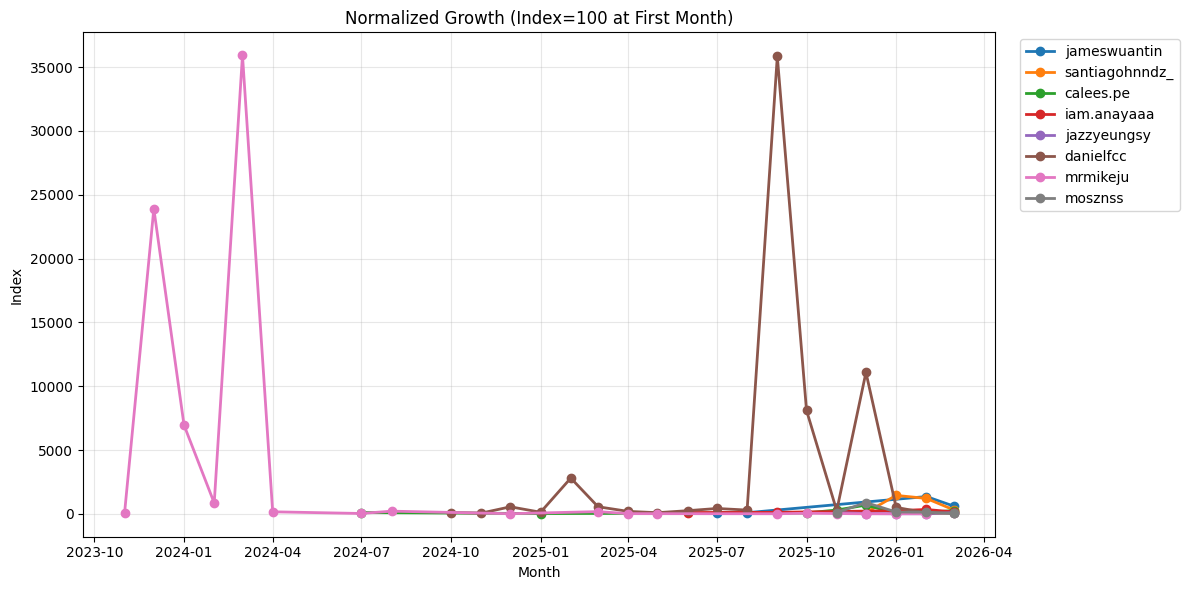

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Reuse df from prior cell; if missing, fail fast with guidance
required_cols = {'username', 'created_at', 'playCount', 'url'}
if 'df' not in globals() or not required_cols.issubset(set(df.columns)):
    raise RuntimeError('Run the temporal analysis cell first to build df.')

user_df = df.copy()
user_df['month_ts'] = user_df['created_at'].dt.to_period('M').dt.to_timestamp()

# Monthly aggregates by user
user_monthly = (
    user_df.groupby(['username', 'month_ts'], as_index=False)
    .agg(
        videos=('url', 'count'),
        total_plays=('playCount', 'sum'),
        avg_plays=('playCount', 'mean'),
    )
    .sort_values(['username', 'month_ts'])
)

# Keep users with at least 3 observed months for meaningful growth trend
months_per_user = user_monthly.groupby('username')['month_ts'].nunique()
eligible_users = months_per_user[months_per_user >= 3].index
user_monthly_eligible = user_monthly[user_monthly['username'].isin(eligible_users)].copy()

if user_monthly_eligible.empty:
    raise ValueError('No users with >= 3 months of history. Lower the threshold if needed.')

# Build first vs last month growth table
first_rows = user_monthly_eligible.groupby('username', as_index=False).first()
last_rows = user_monthly_eligible.groupby('username', as_index=False).last()
growth = first_rows.merge(last_rows, on='username', suffixes=('_first', '_last'))

growth['months_span'] = (
    (growth['month_ts_last'].dt.year - growth['month_ts_first'].dt.year) * 12
    + (growth['month_ts_last'].dt.month - growth['month_ts_first'].dt.month)
    + 1
)
growth['plays_growth_abs'] = growth['total_plays_last'] - growth['total_plays_first']
growth['plays_growth_pct'] = np.where(
    growth['total_plays_first'] > 0,
    (growth['plays_growth_abs'] / growth['total_plays_first']) * 100,
    np.nan,
 )

growth = growth.sort_values('plays_growth_abs', ascending=False)

print(f"Users with >=3 months history: {len(growth):,}")
display(
    growth[[
        'username',
        'month_ts_first',
        'month_ts_last',
        'months_span',
        'total_plays_first',
        'total_plays_last',
        'plays_growth_abs',
        'plays_growth_pct',
    ]].head(20)
 )

# Plot top users by absolute growth
top_users = growth.head(8)['username'].tolist()
plot_df = user_monthly_eligible[user_monthly_eligible['username'].isin(top_users)]

plt.figure(figsize=(12, 6))
for u in top_users:
    s = plot_df[plot_df['username'] == u].sort_values('month_ts')
    plt.plot(s['month_ts'], s['total_plays'], marker='o', linewidth=2, label=u)

plt.title('Monthly Total Plays: Top 8 Users by Growth')
plt.xlabel('Month')
plt.ylabel('Total Plays')
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Optional normalized trend (index=100 at first month) for fair comparison
norm_df = plot_df.copy()
first_play_map = norm_df.sort_values('month_ts').groupby('username')['total_plays'].first()
norm_df['baseline'] = norm_df['username'].map(first_play_map)
norm_df['index_100'] = np.where(norm_df['baseline'] > 0, norm_df['total_plays'] / norm_df['baseline'] * 100, np.nan)

plt.figure(figsize=(12, 6))
for u in top_users:
    s = norm_df[norm_df['username'] == u].sort_values('month_ts')
    plt.plot(s['month_ts'], s['index_100'], marker='o', linewidth=2, label=u)

plt.title('Normalized Growth (Index=100 at First Month)')
plt.xlabel('Month')
plt.ylabel('Index')
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()